# Lecture 5 — Classification & Transfer Learning (Practice)

Этот ноутбук — **практика без оценивания**.  
Цель: руками пройти путь **pretrained → head → freeze/unfreeze → метрики → разбор ошибок**.

Что сделаем:
1) Подготовим данные (CIFAR-10) и правильные transforms под pretrained backbone  
2) Соберём ResNet18 (pretrained) и заменим head  
3) Сравним **freeze (feature extraction)** vs **fine-tuning**  
4) Посмотрим **confusion matrix** и примеры ошибок

Если CIFAR-10 не скачивается, переключитесь на FakeData (в ноутбуке есть переключатель).


In [ ]:
# (Colab) install — обычно уже есть, но на всякий случай
!pip -q install -U torch torchvision torchaudio scikit-learn matplotlib


In [10]:
import os, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams["figure.dpi"] = 140

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


## 1) Transforms под pretrained backbone

Термины:
- **pretrained** — модель уже обучалась на большом датасете (часто ImageNet)
- **normalize mean/std** — входы приводим к ожидаемому распределению (иначе модель «видит другой мир»)


In [11]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## 2) Данные: CIFAR-10 или FakeData

In [12]:
USE_CIFAR10 = True  # переключи на False, если CIFAR-10 не качается

def get_datasets(use_cifar=True):
    if use_cifar:
        train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
        dev_ds   = datasets.CIFAR10(root="./data", train=False, download=True, transform=eval_tf)
        return train_ds, dev_ds, train_ds.classes
    fake_train = datasets.FakeData(size=3000, image_size=(3,224,224), num_classes=10, transform=train_tf)
    fake_dev   = datasets.FakeData(size=800, image_size=(3,224,224), num_classes=10, transform=eval_tf)
    return fake_train, fake_dev, [f"class_{i}" for i in range(10)]

train_ds, dev_ds, class_names = get_datasets(USE_CIFAR10)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2)
dev_loader   = DataLoader(dev_ds, batch_size=BATCH, shuffle=False, num_workers=2)

print("Train size:", len(train_ds), "Dev size:", len(dev_ds))
print("First classes:", class_names[:5])


Files already downloaded and verified
Files already downloaded and verified
Train size: 50000 Dev size: 10000
First classes: ['airplane', 'automobile', 'bird', 'cat', 'deer']


## 3) Модель: ResNet18 pretrained + новый head

In [13]:
def build_resnet18(num_classes: int):
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


In [14]:
model = build_resnet18(num_classes=len(class_names)).to(DEVICE)
print(model.fc)


Linear(in_features=512, out_features=10, bias=True)


## 4) Freeze vs Fine-tuning

In [15]:
def set_trainable(model: nn.Module, mode: str):
    if mode == "freeze":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "finetune":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError("mode must be 'freeze' or 'finetune'")

def count_trainable(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    y_true, y_pred = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        pred = logits.argmax(1)
        correct += int((pred == y).sum().item())
        total += int(y.numel())
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())
    return correct / max(1, total), np.array(y_true), np.array(y_pred)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_n = 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * int(y.numel())
        total_n += int(y.numel())
    return total_loss / max(1, total_n)


In [16]:
def run(mode: str, epochs: int = 1, lr_head=3e-4, lr_backbone=1e-4):
    m = build_resnet18(num_classes=len(class_names)).to(DEVICE)
    set_trainable(m, mode)
    print(f"Mode: {mode}. Trainable params:", count_trainable(m))

    head_params = list(m.fc.parameters())
    backbone_params = [p for n, p in m.named_parameters() if not n.startswith("fc.")]
    opt = torch.optim.AdamW(
        [{"params": backbone_params, "lr": lr_backbone}, {"params": head_params, "lr": lr_head}],
        weight_decay=1e-4
    )

    for e in range(epochs):
        loss = train_one_epoch(m, train_loader, opt)
        acc, _, _ = evaluate(m, dev_loader)
        print(f"epoch {e+1}: loss={loss:.4f}  dev_acc={acc:.4f}")
    return m

m_freeze = run("freeze", epochs=1)
m_ft     = run("finetune", epochs=1)


Mode: freeze. Trainable params: 5130
epoch 1: loss=1.2289  dev_acc=0.7110
Mode: finetune. Trainable params: 11181642
epoch 1: loss=0.3898  dev_acc=0.9208


## 5) Разбор ошибок: confusion matrix и примеры

In [17]:
acc, yt, yp = evaluate(m_ft, dev_loader)
print("Dev acc:", acc)
print(classification_report(yt, yp, target_names=class_names, digits=3))
cm = confusion_matrix(yt, yp)
print("Confusion matrix shape:", cm.shape)


Dev acc: 0.9208
              precision    recall  f1-score   support

    airplane      0.923     0.935     0.929      1000
  automobile      0.945     0.978     0.961      1000
        bird      0.862     0.940     0.900      1000
         cat      0.821     0.870     0.845      1000
        deer      0.942     0.893     0.917      1000
         dog      0.924     0.832     0.876      1000
        frog      0.947     0.928     0.937      1000
       horse      0.947     0.939     0.943      1000
        ship      0.936     0.963     0.949      1000
       truck      0.976     0.930     0.952      1000

    accuracy                          0.921     10000
   macro avg      0.922     0.921     0.921     10000
weighted avg      0.922     0.921     0.921     10000

Confusion matrix shape: (10, 10)


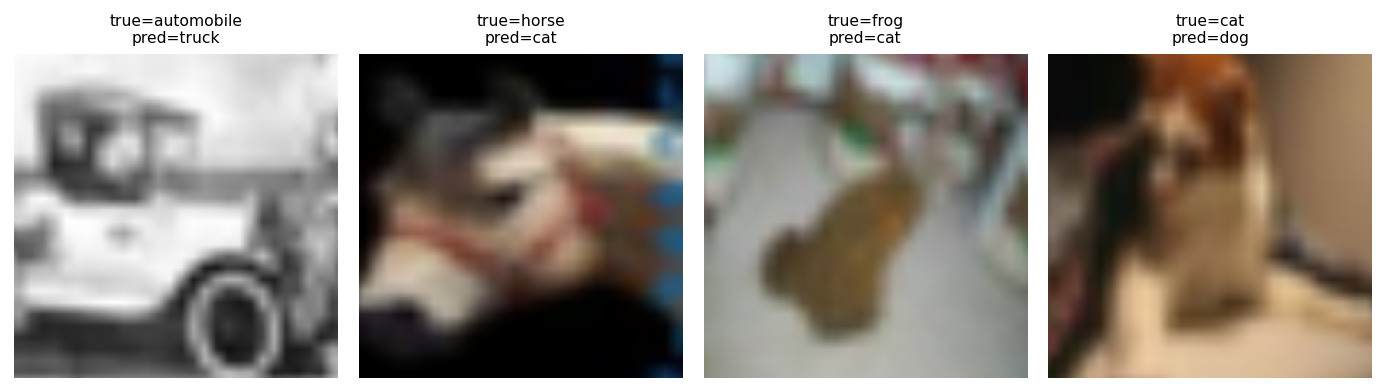

In [18]:
def denorm(img_t):
    mean = torch.tensor(IMAGENET_MEAN)[:, None, None]
    std = torch.tensor(IMAGENET_STD)[:, None, None]
    x = img_t.cpu() * std + mean
    return torch.clamp(x, 0, 1)

m_ft.eval()
x, y = next(iter(dev_loader))
x, y = x.to(DEVICE), y.to(DEVICE)
with torch.no_grad():
    pred = m_ft(x).argmax(1)

wrong_idx = (pred != y).nonzero().flatten()[:12].tolist()
imgs, titles = [], []
for i in wrong_idx:
    img = denorm(x[i]).permute(1,2,0).numpy()
    imgs.append(img)
    titles.append(f"true={class_names[int(y[i])]}\npred={class_names[int(pred[i])]}")

cols = 4
rows = (len(imgs) + cols - 1)//cols
plt.figure(figsize=(10, 7))
for k, (im, t) in enumerate(zip(imgs, titles)):
    ax = plt.subplot(rows, cols, k+1)
    ax.axis("off")
    ax.set_title(t, fontsize=8)
    plt.imshow(im)
plt.tight_layout()
plt.show()
